[Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 2: Structural Patterns, Part 1](02_Structural_Part_1.ipynb)

# GoF 1: Creational Patterns

Creational patterns are about **who creates objects and how**, so that the code using an object does not have to know its concrete class.

**Learning objectives.** After this module you can:

* write a Singleton in Python and explain why a module usually serves better;
* use Factory Method and Abstract Factory to keep client code independent of concrete classes, and tell the two apart;
* build complex objects step by step with Builder and a Director;
* clone configured objects with Prototype.

**Prerequisites.** The tracer and diagram legend in [Start Here](../00_Start_Here.ipynb).

## 1. Singleton

**Problem.** Exactly one instance of something should exist (a configuration, a connection pool), and everyone should reach the same one.

**Structure.** One class that guards its own construction and hands out the single instance.

**When to use it, and when not.** Rarely. A Singleton is a global variable in disguise: tests cannot substitute it, and hidden shared state causes surprising coupling.
In Python a **module** is already a singleton, and a module-level instance you can swap in tests is almost always the better tool.

In [1]:
from dplab import class_diagram, traced, trace

class Config:
    _instance = None

    def __new__(cls, *args, **kwargs):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            cls._instance.settings = {}
        return cls._instance

a = Config()
b = Config()
a.settings["debug"] = True
print("same object?", a is b, "   b sees a's change:", b.settings)

# The Pythonic version: a module-level instance. (Here simulated with a plain class and one instance.)
class Settings:
    def __init__(self):
        self.values = {"debug": False}

settings = Settings()                       # import this from a module; swap it in tests with monkeypatch
print("module-level instance:", settings.values)

same object? True    b sees a's change: {'debug': True}
module-level instance: {'debug': False}


> **What to notice.** `__new__` runs before `__init__` and is where the guard belongs. Note that `__init__` would still run on every `Config()` call,
> another reason the pattern is awkward in Python.

## 2. Factory Method

**Problem.** A class needs to create objects but should not hard-code which concrete class. Different subclasses (or configurations) need different products.

**Structure.** The creator declares a method that returns a product; subclasses override it to choose the concrete product. The rest of the creator's code works with the abstract product.

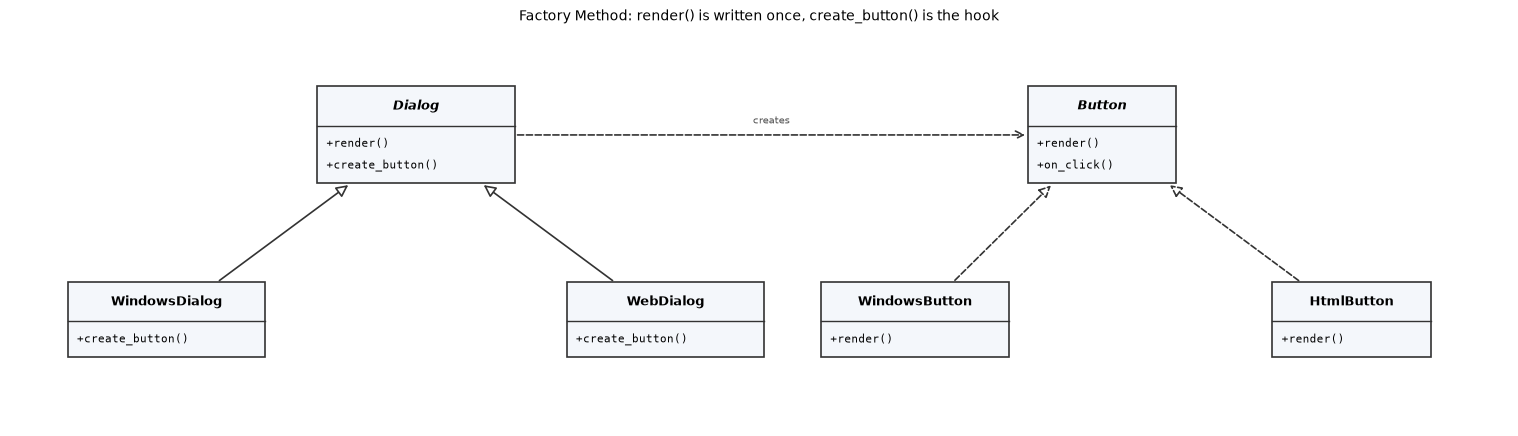

In [2]:
class_diagram(
    {"Dialog": ["+render()", "+create_button()"], "WindowsDialog": ["+create_button()"], "WebDialog": ["+create_button()"],
     "Button": ["+render()", "+on_click()"], "WindowsButton": ["+render()"], "HtmlButton": ["+render()"]},
    [("WindowsDialog", "Dialog", "inherits"), ("WebDialog", "Dialog", "inherits"), ("WindowsButton", "Button", "implements"),
     ("HtmlButton", "Button", "implements"), ("Dialog", "Button", "uses", "creates")],
    abstract={"Dialog", "Button"},
    layout={"Dialog": (-1, 0), "Button": (1.2, 0), "WindowsDialog": (-1.8, 1), "WebDialog": (-0.2, 1), "WindowsButton": (0.6, 1), "HtmlButton": (2.0, 1)},
    title="Factory Method: render() is written once, create_button() is the hook")

dialog with [ Windows button ]
dialog with <button>HTML button</button>


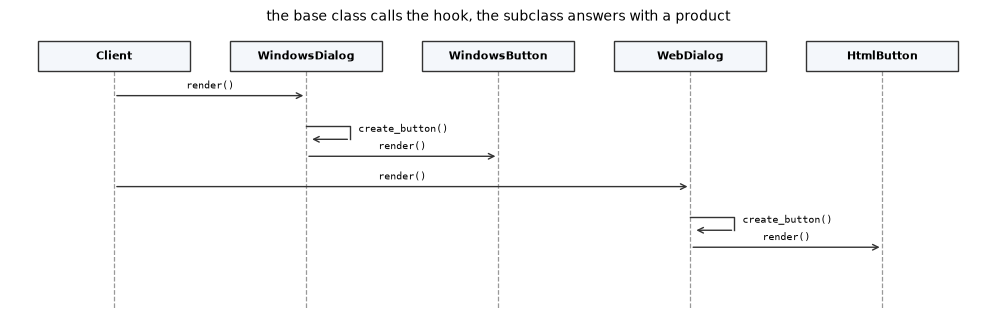

In [3]:
@traced
class WindowsButton:
    def render(self):
        return "[ Windows button ]"

@traced
class HtmlButton:
    def render(self):
        return "<button>HTML button</button>"

@traced
class Dialog:
    def render(self):                        # written once, in the base class
        button = self.create_button()        # the factory method: subclasses decide the product
        return f"dialog with {button.render()}"

    def create_button(self):
        raise NotImplementedError

@traced
class WindowsDialog(Dialog):
    def create_button(self):
        return WindowsButton()

@traced
class WebDialog(Dialog):
    def create_button(self):
        return HtmlButton()

with trace() as t:
    for dialog in (WindowsDialog(), WebDialog()):
        print(dialog.render())
t.diagram(title="the base class calls the hook, the subclass answers with a product")

> **What to notice.** `Dialog.render` never names a concrete button. Adding a `MacDialog` means one new subclass and no change to existing code:
> the open/closed principle in one method. In Python, a plain function or a `classmethod` acting as a factory often does the same job with less ceremony.

## 3. Abstract Factory

**Problem.** Several kinds of objects must be created *to match each other*: a button, a checkbox and a menu for the same look and feel. Mixing a Mac button with a Windows checkbox is a bug.

**Structure.** One factory interface with a creation method per product type; one concrete factory per family. The client is given a factory and never names a concrete class.

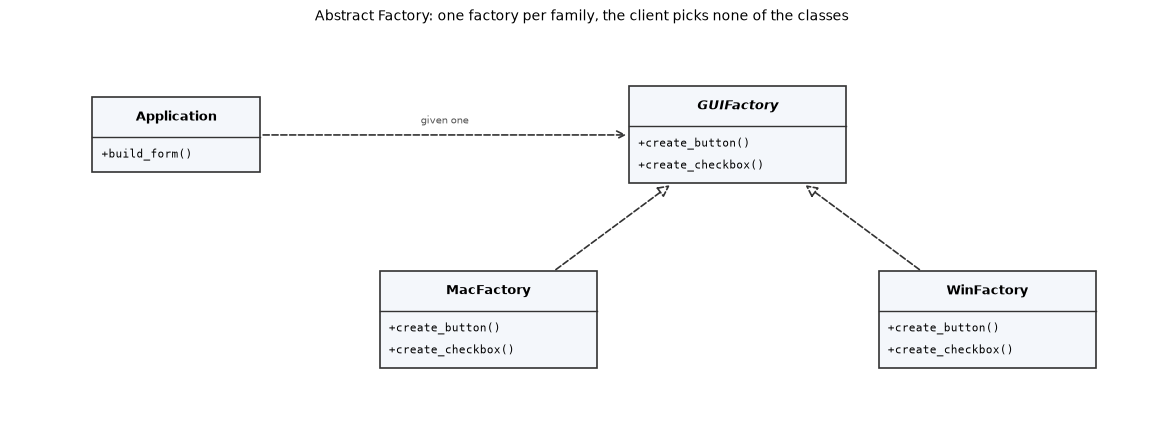

In [4]:
class_diagram(
    {"GUIFactory": ["+create_button()", "+create_checkbox()"], "MacFactory": ["+create_button()", "+create_checkbox()"],
     "WinFactory": ["+create_button()", "+create_checkbox()"], "Application": ["+build_form()"]},
    [("MacFactory", "GUIFactory", "implements"), ("WinFactory", "GUIFactory", "implements"), ("Application", "GUIFactory", "uses", "given one")],
    abstract={"GUIFactory"}, layout={"Application": (-1.3, 0), "GUIFactory": (0.5, 0), "MacFactory": (-0.3, 1), "WinFactory": (1.3, 1)},
    title="Abstract Factory: one factory per family, the client picks none of the classes")

(mac button) (mac checkbox)


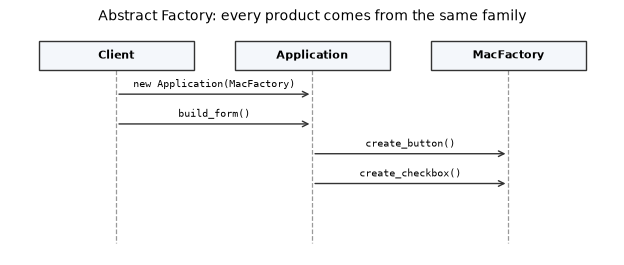

In [5]:
class MacButton:      label = "(mac button)"
class MacCheckbox:    label = "(mac checkbox)"
class WinButton:      label = "[win button]"
class WinCheckbox:    label = "[win checkbox]"

@traced
class MacFactory:
    def create_button(self):   return MacButton()
    def create_checkbox(self): return MacCheckbox()

@traced
class WinFactory:
    def create_button(self):   return WinButton()
    def create_checkbox(self): return WinCheckbox()

@traced
class Application:
    def __init__(self, factory):
        self.factory = factory

    def build_form(self):
        parts = [self.factory.create_button(), self.factory.create_checkbox()]
        return " ".join(p.label for p in parts)

import platform
factory = MacFactory() if platform.system() == "Darwin" else WinFactory()   # the ONE place a concrete class is named
with trace() as t:
    print(Application(factory).build_form())
t.diagram(title="Abstract Factory: every product comes from the same family")

## 4. Builder

**Problem.** Constructing an object takes many optional steps, and the same sequence of steps might need to produce different representations
(a SQL string, a dict, a request object). A constructor with fifteen arguments is the smell.

**Structure.** A builder interface with one method per step; concrete builders produce different products; an optional Director knows the recipes.
Fluent builders return `self` so steps chain.

SELECT * FROM users WHERE active = 1
SELECT id, total FROM orders WHERE total > 100 ORDER BY created_at DESC LIMIT 10


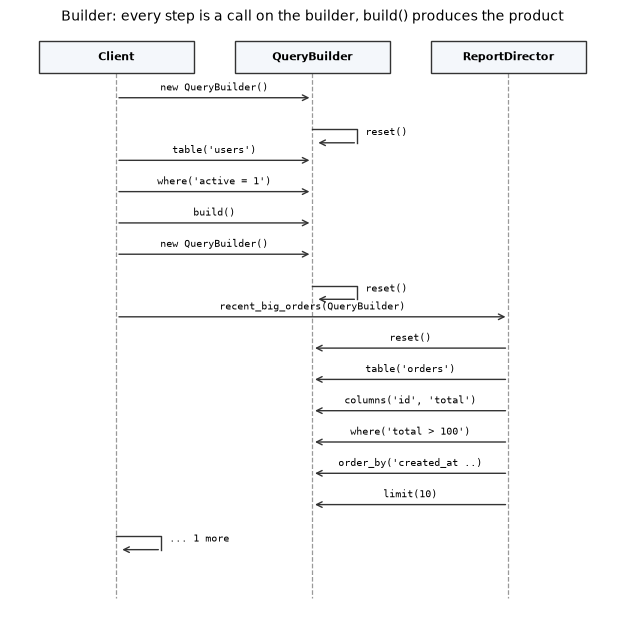

In [6]:
@traced
class QueryBuilder:
    def __init__(self):
        self.reset()

    def reset(self):
        self._table, self._columns, self._where, self._order, self._limit = None, ["*"], [], None, None
        return self

    def table(self, name):        self._table = name;            return self
    def columns(self, *cols):     self._columns = list(cols);    return self
    def where(self, condition):   self._where.append(condition); return self
    def order_by(self, col):      self._order = col;             return self
    def limit(self, n):           self._limit = n;               return self

    def build(self):
        sql = f"SELECT {', '.join(self._columns)} FROM {self._table}"
        if self._where:  sql += " WHERE " + " AND ".join(self._where)
        if self._order:  sql += f" ORDER BY {self._order}"
        if self._limit:  sql += f" LIMIT {self._limit}"
        return sql

@traced
class ReportDirector:
    # Recipes live here, so the same "recent big orders" query is built identically everywhere.
    def recent_big_orders(self, builder):
        return builder.reset().table("orders").columns("id", "total").where("total > 100").order_by("created_at DESC").limit(10).build()

with trace() as t:
    print(QueryBuilder().table("users").where("active = 1").build())
    print(ReportDirector().recent_big_orders(QueryBuilder()))
t.diagram(title="Builder: every step is a call on the builder, build() produces the product", max_messages=14)

### Lab: Builder Lab

Add parts one at a time or let the Director run a recipe, then switch the builder: the same steps now produce JSON instead of a spec sheet.

Builder Lab (static preview). Run this cell in JupyterLab for the interactive version.


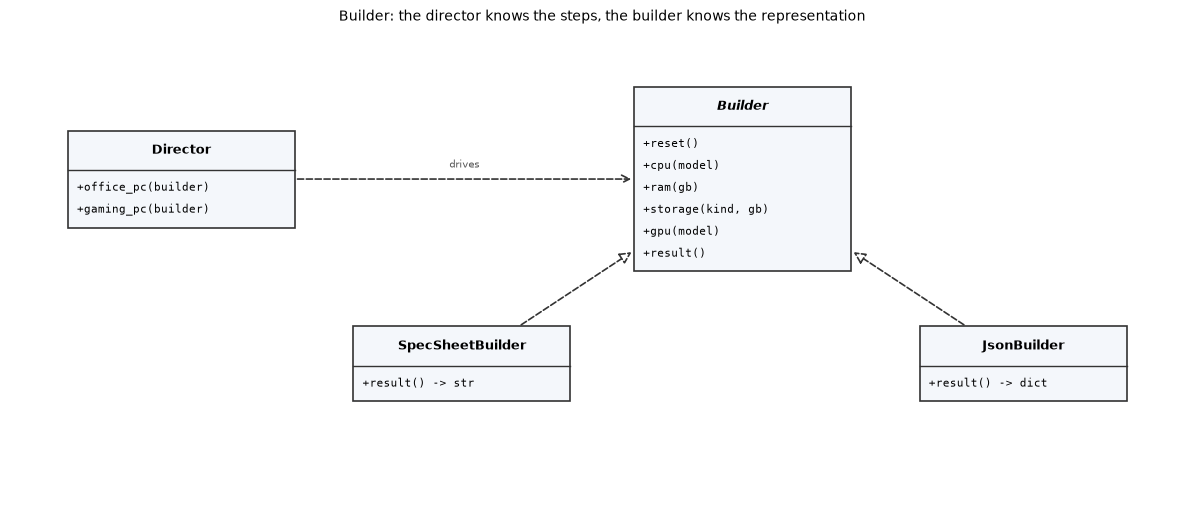

In [7]:
from dplab import builder_lab

builder_lab()

## 5. Prototype

**Problem.** Creating an object is expensive or fiddly (lots of configuration), and you need many similar ones. Copy a configured prototype instead of rebuilding from scratch.

**Structure.** Objects know how to clone themselves. Python hands you `copy.copy` and `copy.deepcopy`; a registry of named prototypes is the usual companion.

In [8]:
import copy

class Document:
    def __init__(self, title, styles, sections):
        self.title, self.styles, self.sections = title, styles, sections

    def clone(self, **changes):
        new = copy.deepcopy(self)               # deep: nested lists and dicts are copied too
        for k, v in changes.items():
            setattr(new, k, v)
        return new

registry = {
    "report": Document("Untitled report", {"font": "Serif", "size": 11}, ["Summary", "Findings", "Appendix"]),
    "memo": Document("Untitled memo", {"font": "Sans", "size": 10}, ["Body"]),
}
q3 = registry["report"].clone(title="Q3 report")
q3.sections.append("Outlook")
print("prototype sections:", registry["report"].sections)      # untouched
print("clone sections:    ", q3.sections, "styles:", q3.styles)

prototype sections: ['Summary', 'Findings', 'Appendix']
clone sections:     ['Summary', 'Findings', 'Appendix', 'Outlook'] styles: {'font': 'Serif', 'size': 11}


> **What to notice.** `deepcopy` matters: with a shallow copy the clone's `sections` list would be the prototype's list, and appending would change both.

## Try it yourself

**Exercise 1.** Replace the `Dialog` Factory Method with a plain function `make_dialog(kind)` that returns the right dialog. Which version is easier to extend, which is easier to read?

**Exercise 2.** Add a `create_menu()` product to the Abstract Factory example and a `LinuxFactory`. How many places did you change?

**Exercise 3.** Add a `join(table, on)` step to `QueryBuilder` and a Director recipe that uses it.

**Exercise 4 (challenge).** Write a Singleton as a decorator: `@singleton` on a class makes every call return the same instance. Then write a test that shows why it is painful to test code that uses it.

<details><summary>Solutions</summary>

```python
# Exercise 1
def make_dialog(kind):
    return {"windows": WindowsDialog, "web": WebDialog}[kind]()
# The function is shorter and fine when the set of kinds is closed; the subclass version lets others extend without editing the dict.

# Exercise 2: one product class per family (3), one method on the factory interface, one new factory. The Application does not change.

# Exercise 3
def join(self, table, on):
    self._joins = getattr(self, "_joins", []) + [f"JOIN {table} ON {on}"]
    return self
QueryBuilder.join = join
# and include " ".join(self._joins) in build() after FROM.

# Exercise 4
def singleton(cls):
    instances = {}
    def get(*a, **k):
        if cls not in instances:
            instances[cls] = cls(*a, **k)
        return instances[cls]
    return get
@singleton
class Cache: pass
assert Cache() is Cache()
# Any test that mutates Cache() leaks state into every other test in the process.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [9]:
from dplab import quiz

quiz(1)

Checkpoint quiz, Module 1 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Which pattern lets a base class define the steps of creating an object while subclasses decide which concrete class to instantiate?
    a) Singleton
    b) Factory Method
    c) Builder
    d) Prototype

Q2. Abstract Factory differs from Factory Method because it creates
    a) one object of one type
    b) families of related objects that must be used together
    c) copies of an existing object
    d) exactly one instance

Q3. Builder is the right choice when
    a) an object needs many optional parts assembled step by step
    b) you need one global instance
    c) you need to copy an object
    d) a class hierarchy has too many subclasses

Q4. The usual objection to Singleton is
    a) it is slow
    b) it is hidden global state that makes tests depend on each other
    c) Python cannot express it
    d) it uses too much memory


## Key takeaways

* Creational patterns move the decision "which class?" out of the code that uses the object.
* Factory Method: a hook in a base class. Abstract Factory: a whole family behind one interface. In Python, functions and classmethods often suffice.
* Builder separates the steps from the representation; a Director stores recipes.
* Prototype is `copy.deepcopy` plus a registry. Singleton is usually a module.

**Next:** patterns about how objects are composed. [GoF 2](02_Structural_Part_1.ipynb).

[Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 2: Structural Patterns, Part 1](02_Structural_Part_1.ipynb)